In [1]:
!nvidia-smi

Fri Oct  2 11:53:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  GRID V100DX-32C                On  |   00000000:06:00.0 Off |                    0 |
| N/A   N/A    P0            N/A  /  N/A  |       1MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, sys

nb_path = './'
sys.path.insert(0,nb_path)

In [3]:
# Install packages
!pip install --no-cache-dir shtns
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
!pip install pyshtools

Defaulting to user installation because normal site-packages is not writeable


In [6]:
!pip install sympy

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import csv
import time
from datetime import datetime
import numpy as np
import pandas as pd
import scipy
from scipy.optimize._numdiff import approx_derivative
import matplotlib.pyplot as plt

import torch
import shtns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

[SHTns 3.7.5] built Jun 13 2026, 12:02:04, id: avx512,ishioka


In [8]:
from math import sqrt, factorial, pi, log
import cmath
from sympy.physics.wigner import wigner_3j
from pyshtools.legendre import PlmIndex, PlmSchmidt_d1

/storage/fi_gt_foldmag_26/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Main utility functions

### Spherical harmonic coefficients of the primary current loop field

In [9]:
def alldredge_loop_sh_coeffs(ns, ms, nmax, K, alpha, r, theta_0, phi_0, r_ref):
    '''
    # Computes the sine and cosine SHCs of order n, degree m for a single current loop
    # Input parameters:
    #-----------------------
    n: SH degree
    m: SH order
    K: normalized magnetic moment
    alpha: half angle of sight from EC to the loop
    r: distance from EC to the edge of the loop
    theta_0: spherical colatitude
    phi_0: spherical longitude
    Output values:
    ----------------------
    gnm sine SHC
    hnm cosine SHC
    '''
    
    a = r_ref#6.378e6 # Earth's radius [m]
    #nm_ind = np.max(np.where(ns==nmax)[0])+1
    n = ns#[:nm_ind]
    m = ms#[:nm_ind]
    
    x = np.cos(alpha)
    legendre_1 = PlmSchmidt_d1(nmax, x, [1,0])[0][PlmIndex(1,n)]
    g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n-1))*(legendre_1/np.sqrt(2*n*(n+1)))
    
    x_m = np.cos(theta_0)
    legendre_m = PlmSchmidt_d1(nmax, x_m, [1,0])[0]
    gnm = g0n*legendre_m*np.cos(m*phi_0)
    hnm = g0n*legendre_m*np.sin(m*phi_0)
    return gnm, hnm

In [10]:
def compute_alldredge_params(original_params, r_ref):
    # Definitions of our original parameters
    theta = original_params[0,:]
    phi = original_params[1,:]
    R = original_params[2,:]
    I = original_params[3,:]
    r = original_params[4,:]
    
    mu0 = 4*pi*1e-7 # Magnetic permeability of free space
    a = r_ref #6.378e6 # Earth's radius [m]
    
    # Parameters definitions of Alldredge's method
    alpha0 = np.atan(R/r)
    r0 = sqrt(R**2+r**2)
    K0 = (10**9*mu0*pi*(r0**2)*(np.sin(alpha0))**2*I)/(a**3)
    theta0 = theta
    phi0 = phi
    return alpha0,r0,K0,theta0,phi0

In [11]:
theta = np.array([np.pi/3])
phi = np.array([np.pi/4])
R = np.array([6e4])
I = np.array([1e5])
r = np.array([3.1e6])

R_e = np.array([3.48e6])#np.array([6.37e6])
R_oc = np.array([3.48e6])

original_params = np.zeros([5,1])
original_params[0,:] = theta
original_params[1,:] = phi
original_params[2,:] = R
original_params[3,:] = I 
original_params[4,:] = r

[alpha0,r0,K0,theta0,phi0] = compute_alldredge_params(original_params = original_params, r_ref = R_oc)

/tmp/ipykernel_177512/1977712234.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r0 = sqrt(R**2+r**2)


In [12]:
lmax = 13
mmax = 13

# Geographic resolution (latitude and longitude)
lat_max = 90
long_max = 180

# Spherical harmonic transformations
sh = shtns.sht(lmax, mmax)
nlat, nphi = sh.set_grid(lat_max, long_max)

In [13]:
ns = np.sort(sh.l)
ms = []
for n in list(range(lmax+1)):
    m_tmp = list(range(n+1))
    ms += m_tmp

In [14]:
ms = np.array(ms)

In [15]:
gnm, hnm = alldredge_loop_sh_coeffs(ns, ms, lmax, K0, alpha0, r0, theta0, phi0, R_oc)

/tmp/ipykernel_177512/2185907250.py:26: RuntimeWarning: divide by zero encountered in divide
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n-1))*(legendre_1/np.sqrt(2*n*(n+1)))
/tmp/ipykernel_177512/2185907250.py:26: RuntimeWarning: invalid value encountered in multiply
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n-1))*(legendre_1/np.sqrt(2*n*(n+1)))


In [16]:
from pyshtools import SHMagCoeffs

In [17]:
def synthesize_magnetic_field(
    degree,
    order,
    gnm,
    hnm,
    r0,
    r_eval=None,
    normalization="schmidt",
    csphase=1,
    units="nT",
    lmax_grid=None,
):
    """
    Synthesize a global magnetic-field grid from Gauss coefficients.

    Parameters
    ----------
    degree, order : array-like of int
        Spherical-harmonic degree n and order m.

    gnm, hnm : array-like of float
        Gauss coefficients g_n^m and h_n^m.

    r0 : float
        Reference radius of the coefficients. Use the same length unit
        everywhere, for example metres or kilometres.

    r_eval : float or None
        Radius at which the field is evaluated. If None, r_eval = r0.

    normalization : str
        One of "schmidt", "4pi", "ortho", or "unnorm".

    csphase : int
        1 means that the Condon-Shortley phase is excluded.
        -1 means that it is included.

    units : str
        Units of the Gauss coefficients, for example "nT".

    lmax_grid : int or None
        Maximum degree supported by the output sampling grid.
        If None, it is set equal to Nmax.

    Returns
    -------
    magnetic_grid : pyshtools.SHMagGrid
        Object containing radial, theta, phi, total-field, and
        magnetic-potential grids.
    """
    degree = np.asarray(degree, dtype=int)
    order = np.asarray(order, dtype=int)
    gnm = np.asarray(gnm, dtype=float)
    hnm = np.asarray(hnm, dtype=float)

    if not (degree.shape == order.shape == gnm.shape == hnm.shape):
        raise ValueError(
            "degree, order, gnm, and hnm must have identical shapes."
        )

    if np.any(order < 0) or np.any(order > degree):
        raise ValueError("Each coefficient must satisfy 0 <= m <= n.")

    nmax = int(np.max(degree))

    # coeffs[0, n, m] stores g_n^m
    # coeffs[1, n, m] stores h_n^m
    coeffs = np.zeros((2, nmax + 1, nmax + 1), dtype=float)

    coeffs[0, degree, order] = gnm
    coeffs[1, degree, order] = hnm

    # h_n^0 multiplies sin(0 phi), so it has no physical contribution.
    coeffs[0, :, 0] = 0.0
    coeffs[1, :, 0] = 0.0

    magnetic_coeffs = SHMagCoeffs.from_array(
        coeffs,
        r0=r0,
        normalization=normalization,
        csphase=csphase,
        units=units,
    )

    if r_eval is None:
        r_eval = r0

    if lmax_grid is None:
        lmax_grid = nmax

    magnetic_grid = magnetic_coeffs.expand(
        a=r_eval,
        f=0.0,
        lmax=lmax_grid,
        lmax_calc=nmax,
        sampling=2,
        extend=True,
    )

    return magnetic_grid

In [18]:
B_r_reconstr = synthesize_magnetic_field(
    degree=ns,
    order=ms,
    gnm=gnm,
    hnm=hnm,
    r0=R_e,
    r_eval=R_oc,
    normalization="schmidt",
    csphase=1,
    units="nT",
    lmax_grid=None,
)

(<Figure size 640x320 with 2 Axes>, <Axes: >)

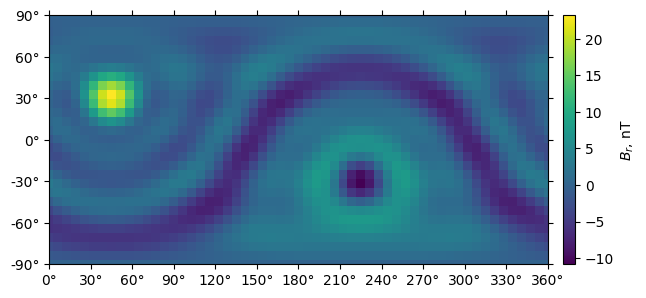

In [19]:
B_r_reconstr.plot_rad()

## Transform gnm and hnm array to shtns-indexed arrays

In [20]:
def rearrange_gauss_coeffs_to_shtns(gnm, hnm):
    '''
    # Rearrange SH Gauss coefficient arrays to shtns indexed arrays
    # Input parameters:
    #-----------------------
    gnm: SH sine Gauss coefficients of SH degree n and order m 
    hnm: SH cosine Gauss coefficients of SH degree n and order m 
    
    Output values:
    ----------------------
    gnm_shtns: SH sine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    hnm_shtns: SH cosine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    '''
    gnm_w_idx = np.array([gnm,ns,ms]).T
    gnm_shtns = np.array([np.zeros([len(gnm),]), sh.l, sh.m]).T
    hnm_w_idx = np.array([hnm,ns,ms]).T
    hnm_shtns = np.array([np.zeros([len(hnm),]), sh.l, sh.m]).T
    for row in range(gnm_w_idx.shape[0]):
        gnm_shtns[row,0] = gnm_w_idx[np.where(np.all(gnm_shtns[row,1:]==gnm_w_idx[:,1:], axis=1))[0],0]
    for row in range(gnm_w_idx.shape[0]):
        hnm_shtns[row,0] = hnm_w_idx[np.where(np.all(hnm_shtns[row,1:]==hnm_w_idx[:,1:], axis=1))[0],0]
    return gnm_shtns, hnm_shtns

In [21]:
# gnm_w_idx = np.array([gnm,ns,ms]).T

In [22]:
# gnm_shtns = np.array([np.zeros([len(gnm),]), sh.l, sh.m]).T

In [23]:
# for row in range(gnm_w_idx.shape[0]):
#     gnm_shtns[row,0] = gnm_w_idx[np.where(np.all(gnm_shtns[row,1:]==gnm_w_idx[:,1:], axis=1))[0],0]

In [24]:
# hnm_w_idx = np.array([hnm,ns,ms]).T
# hnm_shtns = np.array([np.zeros([len(hnm),]), sh.l, sh.m]).T

In [25]:
# for row in range(gnm_w_idx.shape[0]):
#     hnm_shtns[row,0] = hnm_w_idx[np.where(np.all(hnm_shtns[row,1:]==hnm_w_idx[:,1:], axis=1))[0],0]

## Convert the shtns Gauss coefficients to poloidal coefficients

In [26]:
def gauss_to_poloidal(gnm_shtns, hnm_shtns):
    '''
    # Computes the radial, spheroidal and poloidal SH coefficients from the Gauss coefficients of a given magnetic field data referenced at a given radial surface
    # Input parameters:
    #-----------------------
    gnm_shtns: SH sine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    hnm_shtns: SH cosine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    Output values:
    ----------------------
    Qlm radial SHC of degree l and order m arranged via shtns indexing
    Slm spheroidal SHC of degree l and order m arranged via shtns indexing
    Tlm toroidal SHC of degree l and order m arranged via shtns indexing
    '''
    
    Glm = gnm_shtns[:,0] - 1j * hnm_shtns[:,0]
    
    # 3. Initialize SHTns spectral arrays for the vector field
    Qlm = sh.spec_array()  # Radial component
    Slm = sh.spec_array()  # Spheroidal component
    Tlm = sh.spec_array()  # Toroidal component (remains 0 for external potential field)
    
    # 4. Apply Schmidt semi-normalized to Orthonormal correction if needed
    # SHTns provides normalization utilities. If your SHTns instance was 
    # explicitly created with Schmidt norm, N_norm = 1.0.
    # Otherwise, convert Schmidt to Orthonormal:
    N_norm = np.zeros(sh.nlm)
    for i in range(sh.nlm):
        l = sh.l[i]
        m = sh.m[i]
        if l > 0:
            # Standard scaling factor from Schmidt semi-normalized to Orthonormal
            # SHTns default is orthonormal
            N_norm[i] = np.sqrt((2 * l + 1) / (4 * np.pi))

    # 5. Convert to Spheroidal (S_lm) and Radial (Q_lm) coefficients
    # Avoid division by zero at l=0
    valid_l = sh.l > 0
    Slm[valid_l] = (1.0 / sh.l[valid_l]) * N_norm[valid_l] * Glm[valid_l]
    Qlm[valid_l] = sh.l[valid_l] * (sh.l[valid_l] + 1) * Slm[valid_l]
    Tlm[:] = 0.0  # No toroidal component for a potential gradient field

    return Slm, Qlm, Tlm

In [27]:
def define_3d_grid_for_vector_SH_transform(sh, theta_mesh, lambda_mesh):
    r = sh.spat_array()  # a spatial array, same as numpy.zeros(sh.spat_shape)
    r[:,:] = 3.48e6
    t = r.copy()
    t[:, :] = theta_mesh
    l = r.copy()
    l[:, :] = lambda_mesh
    return r, t, l

In [79]:
# Glm = gnm_shtns[:,0] - 1j * hnm_shtns[:,0]

In [80]:
# # 3. Initialize SHTns spectral arrays for the vector field
# Qlm = sh.spec_array()  # Radial component
# Slm = sh.spec_array()  # Spheroidal component
# Tlm = sh.spec_array()  # Toroidal component (remains 0 for external potential field)

In [81]:
# # 4. Apply Schmidt semi-normalized to Orthonormal correction if needed
# # SHTns provides normalization utilities. If your SHTns instance was 
# # explicitly created with Schmidt norm, N_norm = 1.0.
# # Otherwise, convert Schmidt to Orthonormal:
# N_norm = np.zeros(sh.nlm)
# for i in range(sh.nlm):
#     l = sh.l[i]
#     m = sh.m[i]
#     if l > 0:
#         # Standard scaling factor from Schmidt semi-normalized to Orthonormal
#         # SHTns default is orthonormal
#         N_norm[i] = np.sqrt((2 * l + 1) / (4 * np.pi))

In [82]:
# # 5. Convert to Spheroidal (S_lm) and Radial (Q_lm) coefficients
# # Avoid division by zero at l=0
# valid_l = sh.l > 0

# Slm[valid_l] = (1.0 / sh.l[valid_l]) * N_norm[valid_l] * Glm[valid_l]
# Qlm[valid_l] = sh.l[valid_l] * (sh.l[valid_l] + 1) * Slm[valid_l]
# Tlm[:] = 0.0  # No toroidal component for a potential gradient field

In [28]:
gnm_shtns, hnm_shtns = rearrange_gauss_coeffs_to_shtns(gnm, hnm)
Slm, Qlm, Tlm = gauss_to_poloidal(gnm_shtns, hnm_shtns)

/tmp/ipykernel_177512/717506432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gnm_shtns[row,0] = gnm_w_idx[np.where(np.all(gnm_shtns[row,1:]==gnm_w_idx[:,1:], axis=1))[0],0]
/tmp/ipykernel_177512/717506432.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hnm_shtns[row,0] = hnm_w_idx[np.where(np.all(hnm_shtns[row,1:]==hnm_w_idx[:,1:], axis=1))[0],0]


In [29]:
theta_arr = np.linspace(0,pi,90)
lambda_arr = np.linspace(0,2*pi,180)
theta_mesh, lambda_mesh = np.meshgrid(theta_arr, lambda_arr)
Vr, Vt, Vp = define_3d_grid_for_vector_SH_transform(sh, theta_mesh.T, lambda_mesh.T)

In [30]:
# Now (Qlm, Slm, Tlm) represent the vector fields in SHTns
# You can directly synthesize them to a spatial grid:
sh.SHqst_to_spat(Qlm, Slm, Tlm, Vr, Vt, Vp)

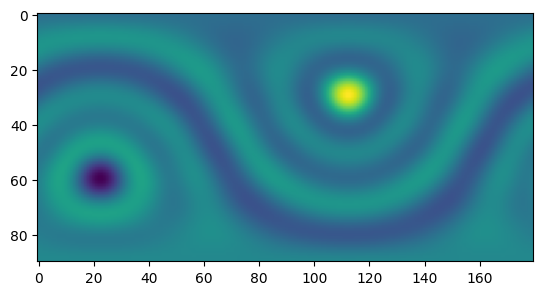

In [31]:
plt.imshow(Vr)

## Generate the function $S_\gamma(r,t=0)$ for $nr_r_samples$ radial evaluation points.

In [32]:
theta = np.array([np.pi/3])
phi = np.array([np.pi/4])
R = np.array([6e4])
I = np.array([1e5])
r = np.array([3.1e6])

R_e = np.array([3.48e6])#np.array([6.37e6])
R_oc = np.array([3.48e6])

original_params = np.zeros([5,1])
original_params[0,:] = theta
original_params[1,:] = phi
original_params[2,:] = R
original_params[3,:] = I 
original_params[4,:] = r

[alpha0,r0,K0,theta0,phi0] = compute_alldredge_params(original_params = original_params, r_ref = R_oc)

/tmp/ipykernel_177512/1977712234.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r0 = sqrt(R**2+r**2)


In [34]:
len(gnm)

105

In [38]:
R_icb = 1.22e6
nr_r_samples = 100
gamma_max = 105

r_samples_dimensional = np.linspace(R_icb, R_oc, nr_r_samples)
S0_r = torch.zeros([nr_r_samples, gamma_max]).to(device) # torch.zeros([globals()['nr_r_samples'],globals()['gamma_max']]).to(device)
r_ind = 0
for r_ref in r_samples_dimensional:
    gnm, hnm = alldredge_loop_sh_coeffs(ns, ms, lmax, K0, alpha0, r0, theta0, phi0, r_ref)
    gnm_shtns, hnm_shtns = rearrange_gauss_coeffs_to_shtns(gnm, hnm)
    Slm, Qlm, Tlm = gauss_to_poloidal(gnm_shtns, hnm_shtns)
    S0_r[r_ind, :] = torch.tensor(Slm).to(device)
    r_ind += 1

/tmp/ipykernel_177512/2185907250.py:26: RuntimeWarning: divide by zero encountered in divide
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n-1))*(legendre_1/np.sqrt(2*n*(n+1)))
/tmp/ipykernel_177512/2185907250.py:26: RuntimeWarning: invalid value encountered in multiply
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n-1))*(legendre_1/np.sqrt(2*n*(n+1)))
/tmp/ipykernel_177512/717506432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gnm_shtns[row,0] = gnm_w_idx[np.where(np.all(gnm_shtns[row,1:]==gnm_w_idx[:,1:], axis=1))[0],0]
/tmp/ipykernel_177512/717506432.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hnm_shtns[row,0] = hnm_w_idx[np

In [40]:
S0_r.shape

torch.Size([100, 105])

### Galerkin basis functions and derivatives

In [41]:
# ============================================================
# Jacobi polynomials (vectorized, no tensor recreation)
# ============================================================
def jacobi_recurrence_for_GPU(power, alpha, beta, x):
    if power < 0:
        return torch.zeros_like(x)

    J0 = torch.ones_like(x)
    if power == 0:
        return J0

    J1 = 0.5 * (alpha + beta + 2) * x + 0.5 * (alpha - beta)
    if power == 1:
        return J1

    J_prev = J0
    J_curr = J1

    for n in range(2, power + 1):
        an = (2*(n-1)+alpha+beta+1)*(2*(n-1)+alpha+beta+2) / (2*n*(n+alpha+beta))
        bn = (beta**2 - alpha**2)*(2*(n-1)+alpha+beta+1) / (2*n*(n+alpha+beta)*(2*(n-1)+alpha+beta))
        cn = (n+1+alpha)*(n+1+beta)*(2*(n+1)+alpha+beta+2) / ((n+2)*(n+alpha+beta+2)*(2*(n+1)+alpha+beta))

        J_next = (an * x - bn) * J_curr - cn * J_prev
        J_prev = J_curr
        J_curr = J_next

    return J_curr


# ============================================================
# Psi computation (vectorized)
# ============================================================
def compute_all_Psi_SL(r, sh_two_index, band_nr, min_pol_degr):
    
    r = r.to(device)
    z = 2 * r**2 - 1

    degree = el[sh_two_index]
    alpha = 0.5
    beta = degree + 0.5


    #######
    Psi = -r**(degree+1)*(-6*alpha-4*degree*alpha+4*degree*alpha*r**2+2*alpha*r**2-24*degree+9*r**2+20*degree*r**2+4*degree**2*r**2-4*degree**2-27) 
 

    Psi_vals = []

    for k in range(min_pol_degr, band_nr):
        if k == 1:
            Psi = -r**(degree+1)*(-6*alpha-4*degree*alpha+4*degree*alpha*r**2+2*alpha*r**2-24*degree+9*r**2+20*degree*r**2+4*degree**2*r**2-4*degree**2-27)
        else:
            c = torch.zeros(3, device=device)
            c[0] = k*(2*degree+5+2*alpha+2*k)*(2*k*alpha**2+2*degree*alpha**2-alpha**2+2*k**2*alpha+5*k*alpha-3*alpha+6*degree*alpha+2*degree*alpha*k-3+4*k**2+2*degree+4*k*degree+2*k)*(2*degree+1+2*alpha+4*k)  
            c[1] = -(1+2*k+2*degree)*(k+2+alpha)*(2*degree+3+2*alpha+4*k)*(2*alpha**3+2*degree*alpha**2+4*k*alpha**2+11*alpha**2+15*alpha+4*k**2*alpha+14*k*alpha+6*degree*alpha+4*degree*alpha*k+8*k**2+8*k*degree+12*k)
            c[2] = (1+2*k+2*degree)*(k+2+alpha)*(alpha**2+2*k*alpha**2+2*degree*alpha**2+4*alpha+8*degree*alpha+2*k**2*alpha+2*degree*alpha*k+9*k*alpha+6*degree+4*k*degree+4*k**2+3+10*k)*(2*degree+5+2*alpha+4*k)
            jacobi_vec = torch.stack([
                jacobi_recurrence_for_GPU(k, alpha+2, beta, z),
                jacobi_recurrence_for_GPU(k-1, alpha+2, beta, z),
                jacobi_recurrence_for_GPU(k-2, alpha+2, beta, z),
            ])

            Psi = r**(degree+1)*torch.matmul(c, jacobi_vec) #

        #TODO: replace .append in the below line w. torch.cat
        Psi_vals.append(Psi)

    return torch.stack(Psi_vals)  # shape: [band_nr-1, N]



In [42]:
def create_vector_of_galerkin_polynomials_SL(min_pol_degr, gamma_two_index, normalization_mx, band_nr, r, el):
    """
    Constructing the Galerkin-base at each observation radius containing basis functions of each polynomial degree used
     for inverting the coefficients of the Galerkin-representation of the induced field
    :param min_pol_degr: degree-based multiplier
    :param gamma_two_index: SH two-index gamma of the induced field
    :param normalization_mx: array A containing the normalization constants
    :param band_nr: maximum polynomial degree used for the representation
    :param r: radial observation point
    :param el: array containing all SH degrees
    :return: [A^1_{\gamma}Psi^1_{\gamma}(r), A^2_{\gamma}Psi^2_{\gamma}(r), ..., A^K_{\gamma}Psi^K_{\gamma}(r)]
    """
    psi_val = compute_all_Psi_SL(r, gamma_two_index, band_nr, min_pol_degr)
    psi_vec = torch.mul(torch.squeeze(psi_val), torch.squeeze(normalization_mx[:,gamma_two_index].T))
    return psi_vec


In [43]:
# =======================================================================
# Normalization coefficients as integrals of unnormalised basis functions
# =======================================================================
def normalization_coeffs_gram_schmidt_SL(sh_two_index, r0, r1, resolution, band_nr, el, min_pol_degr):
    alpha = 0.5

    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi_SL(r, sh_two_index, band_nr, min_pol_degr)

    # normalization
    Psi_abs = torch.abs(Psi_vals)

    weight = (1-r**2)**alpha

    # Compute all integrals at once
    B_norm_gs = torch.einsum('ir,jr,r->ij', Psi_abs, Psi_abs, weight) * dr

    return B_norm_gs
# ===================================================================================================
# NEW VERSION OF NORMALIZATION CONSTANTS <- ENSURING THE ORTHONORMAL CONDITION FOR THE GALERKING BASE
# [GRAM-SCHMIDT PROCEDURE]
# ===================================================================================================
def derive_normalization_constant_orthonormal(band_nr, min_pol_degr, max_sh_two_index, B_norm_gs):
    gram_schmidt_norm_mx = torch.ones([band_nr-min_pol_degr, max_sh_two_index], device=device)

    for sh_two_index in range(1, max_sh_two_index):
        gram_schmidt_norm_mx[:, sh_two_index] = 1/torch.sqrt(torch.diag(B_norm_gs[:,:,sh_two_index]))
    return gram_schmidt_norm_mx

### SH analysis

In [44]:
# Schmidt-normalized Legendre polynomials
def P(k, l, theta):
    P, dthet_P = PlmSchmidt_d1(k, torch.cos(theta), [1, 0])
    return P[PlmIndex(k,l)], dthet_P[PlmIndex(k,l)]

# Derivatives of Legendre polynomials
#---------------------------------------------------------------------
def derivative_in_theta(k, l, theta):
    return -torch.sin(theta)*P(k,l,theta)[1]

def Y_derivative_in_theta(k, l, theta, phi):
    dP = derivative_in_theta(k, l, theta)
    return (-torch.sin(theta))*(-1)**l*sqrt(((2*k+1)*factorial(k-l))/(factorial(k+l)))*dP*torch.exp(1j*torch.Tensor([1.0]).to(device)*l*phi)

In [45]:
#-------------------------- COMPUTE THE TOROIDAL SH COEFFICIENTS OF A PRESCRIBED AZIMUTHAL FLOW --------------------------------------
def compute_toroidal_flow_coefficients_vectorized(r, Omega, R_oc):
    return Omega * r * R_oc

In [46]:
#-------------------------- COMPUTE THE SH COEFFICIENTS FROM GIVEN SOURCE MF DATA --------------------------------------
def define_3d_grid_for_vector_SH_transform(sh):
    x = sh.spat_array()  # a spatial array, same as numpy.zeros(sh.spat_shape)
    y = x.copy()
    y[:, :] = 0
    z = x.copy()
    z[:, :] = 0
    return x, y, z


def compute_poloidal_source_coefficients(Br_test, x, y, z, sh, r_samples, r_ind, R_oc):
    """
    Performs the spherical harmonic analysis on a map of source field values using an instance of the shtns package (sh)
    with three arguments, sh.alanys() performs a 3D vector transform (spherical coordinates)
    :param Br_test: stack of geographic maps (radial slices) of source field values
    :param x: starting grid
    :param y:
    :param z:
    :param sh: an instance of the shtns package
    :param r_samples: radial sampling points for geomagnetic map slices
    :param r_ind: index of the given geocentric radius of a slice
    :return: S0_r source coefficients; el array of size sh.nlm giving the SH degree l for any SH coefficient,
    l2 array l(l+1) that is useful for computing laplacian
    """
    # TODO: CHECK FOR POSSIBLE APPLICATION OF GPU VERSION HERE! - shtns also has a GPU implementation
    x[:, :] = torch.squeeze(Br_test[:, :, r_ind]).cpu().numpy()
    qlm, slm, tlm = sh.analys(x, y,
                              z)
    el = sh.l 
    em = sh.m
    l2 = el * (el + 1)
    r_dimensional = r_samples[r_ind]*R_oc
    qlm = torch.Tensor(qlm).to(device)
    l2 = torch.Tensor(l2).to(device)
    S0_r = (qlm * r_dimensional) / (l2 + 1)
    return S0_r, el, em, l2


In [47]:
# -------------------------ELSASSER DYNAMO INTEGRAL AS FEATURED IN [5] --------------------------------------------------
def elsasser(n,m,k,l,i,j):
    """
    Evaluates the Elsasser dynamo integral for each corresponding SH degree and order listed below
    :param n: flow order n_gamma
    :param m: flow degree m_gamma
    :param k: source mf order k_beta
    :param l: source mf degree l_beta
    :param i: induced mf order i_gamma
    :param j: induced mf degree j_gamma
    :return: elsasser_nm value of the Elsasser dynamo integral
    """
    Lambda_b_g = cmath.sqrt((2 * n + 1)*(2 * k + 1)*(2 * i + 1))
    Delta_b_g = cmath.sqrt((n + k + i + 2)*(n + k + i + 4) / (4 * (n + k + i + 3))) * cmath.sqrt((n + k - i + 1)*(n + i - k + 1)*(i + k - n + 1))
    elsasser_nm = (-1)**np.float32(j)*(-4j*pi*Lambda_b_g*Delta_b_g*wigner_3j(n+1, k+1, i + 1, 0, 0, 0)*wigner_3j(n, k, i, m, l, j))
    return elsasser_nm

# GLOBAL DEFINITIONS

## Global definitions of basic quantities

In [48]:
# ============================================================
# PHYSICAL QUANTITIES
# ============================================================

# Outer core radius
global R_oc
R_oc = 3.48e6

# Permeability of empty space
global mu_0 
mu_0 = 4 * np.pi * 1e-7

# Core conductivity
sigma = 1e6 # older estimate is 5e5 [S/m]
global eta 
eta = 1 / (mu_0 * sigma)

# Angular velocity of the rotating flow
global Omega 
# Omega = 1.2e-10  # FOR AVG OUTER CORE VELOCITIES: v_oc(~10[km/yr])/r_oc(~2500[km])[1/s]
Omega = 5*1.2e-10  # FOR MAX POTENTIAL OUTER CORE VELOCITIES: v_oc(~50[km/yr])/r_oc(~2500[km])[1/s]

# Normalized spherical domain extension
global r0 
r0 = 0.0
global r1 
r1 = 1.0
# Number of radial sample (observation) points
global nr_r_samples 
nr_r_samples = 100
# Sample radii
global r_samples 
r_samples = torch.linspace(0.01, 1, nr_r_samples, device=device)

# ============================================================
# SPHERICAL HARMONIC DESCRIPTION
# ============================================================
# Geographic resolution (latitude and longitude)
lat_max = 90
long_max = 180

# Spherical harmonic resolution (degree and order)
# lmax = 5
# mmax = 5
lmax = 13
mmax = 13

# Spherical harmonic transformations
global sh 
sh = shtns.sht(lmax, mmax)
nlat, nphi = sh.set_grid(lat_max, long_max)

global el 
el = sh.l
global em 
em = sh.m
global l2 
l2 = el * (el + 1)

# Maximum primary source mf two-indexes
global beta_max 
#beta_max = 21
beta_max = len(el)

# First index of the iteration of SH indices
global gamma_first_index
gamma_first_index = 1
# Maximum induced mf two-indexes
global gamma_max
gamma_max = len(em)

# Alpha indices - for the toroidal flow coefficient - FIXED
global n 
n = 1
global m 
m = 0

# ============================================================
# GALERKIN REPRESENTATION
# ============================================================
# Maximum degree of basis functions
global band_nr 
band_nr = 14
# Minimum degree of basis functions
global min_pol_degr
min_pol_degr = 2 #min_pol_degr = base_degr-1 [3-1=2] - nr_of_different_boundary_conds [1] +1 = 2 see in Livermore's compendium 1.6: n>=N-M+1
# Resolution of numerical integrations
global resolution 
resolution = 100

## Globally utilized preallocated arrays

### Gram-Schmidt normalization of the Galerkin base

In [49]:
B_norm_gs_local = torch.zeros([globals()['band_nr']-globals()['min_pol_degr'], globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)

for gamma_two_index in range(1,globals()['gamma_max']):
    B_norm_gs_local[:,:,gamma_two_index] = normalization_coeffs_gram_schmidt_SL(gamma_two_index, globals()['r0'], globals()['r1'], globals()['resolution'], globals()['band_nr'], globals()['el'], globals()['min_pol_degr'])

global B_norm_gs
B_norm_gs = B_norm_gs_local
del B_norm_gs_local

In [50]:
# ============================================================
# NORMALIZATION
# ============================================================
global normalization_mx 
normalization_mx = derive_normalization_constant_orthonormal(globals()['band_nr'], globals()['min_pol_degr'], globals()['gamma_max'], globals()['B_norm_gs']) 

## Loading primary source field magnetic induction data (radial component)

In [51]:
global Br_test
Br_test = torch.Tensor(np.array(scipy.io.loadmat('B_r_test.mat')['B_r'])).to(device)

# Computing values of the matrix $\mathbf{Psi}_{\gamma}^k(r)$ containing the Galerkin base functions

In [53]:
#TODO: CHECK WHETHER THE SAME RESULT CAN BE OBTAINED FASTER USING THE FULL VECTOR "r_samples" INSTEAD OF single values "r" in the computations
psi_tmp_local = torch.zeros([globals()['nr_r_samples'], globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)
r_ind = 0
for r in r_samples:
    print(r_ind, flush=True)
    for gamma_two_index in range(1, globals()['gamma_max']):
        mu = 1 / l2[gamma_two_index]
        psi_tmp_local[r_ind, :, gamma_two_index] = create_vector_of_galerkin_polynomials_SL(globals()['min_pol_degr'], gamma_two_index, globals()['normalization_mx'], globals()['band_nr'], r, globals()['el'])
    r_ind += 1
global PSI_MATRIX
PSI_MATRIX = psi_tmp_local
del psi_tmp_local

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


# Computing base function derivatives $\frac{d(\Psi_{\gamma}^k(r))}{dr}$ for the boundary condition:
# $\mu\frac{d(S_{\gamma}(r))}{dr}(r=1) + S_{\gamma}(r=1) = 0$

In [55]:
psi_prime_local = torch.zeros([globals()['nr_r_samples'], globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)
for gamma_two_index in range(1, globals()['gamma_max']):
    for k in range(globals()['band_nr']-globals()['min_pol_degr']):
        psi_prime_local[:,k,gamma_two_index] = torch.gradient(globals()['PSI_MATRIX'][:,k, gamma_two_index])[0]
global PSI_PRIME_MX
PSI_PRIME_MX = psi_prime_local
del psi_prime_local

# Examining the properties of the Elsasser dynamo integral

In [56]:
Elsasser_tmp = torch.zeros([globals()['gamma_max']+1,globals()['beta_max']+1], dtype=torch.complex64).to(device)
for gamma_two_index in range(1, globals()['gamma_max']):
    i = globals()['el'][gamma_two_index]
    j = globals()['em'][gamma_two_index]
    for beta_two_index in list(range(1, globals()['beta_max'])):
        k = globals()['el'][beta_two_index]
        l = globals()['em'][beta_two_index]
        Elsasser_tmp[gamma_two_index,beta_two_index] = torch.tensor([complex(elsasser(globals()['n'], globals()['m'], k, l, i, -j))], dtype=torch.complex64).to(device)

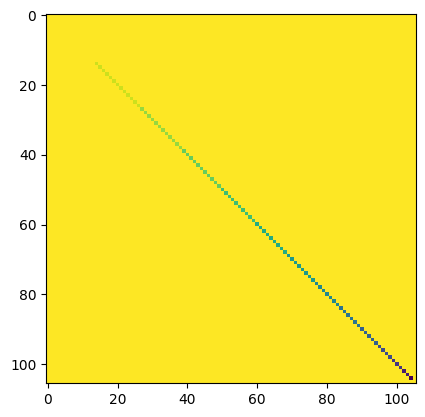

In [57]:
plt.imshow(torch.imag(Elsasser_tmp).cpu().numpy())

## Storing results of the Elsasser dynamo integral $E_{1,\gamma,\beta}^*$ for every SH degree and order 

In [58]:
Elsasser_tmp_for_global = torch.zeros([globals()['lmax']+1,globals()['mmax']+1,globals()['lmax']+1,globals()['mmax']+1], dtype=torch.complex64).to(device)
for gamma_two_index in range(1, globals()['gamma_max']):
    i = globals()['el'][gamma_two_index]
    j = globals()['em'][gamma_two_index]
    for beta_two_index in list(range(1, globals()['beta_max'])):
        k = globals()['el'][beta_two_index]
        l = globals()['em'][beta_two_index]
        Elsasser_tmp_for_global[i,j,k,l] = torch.tensor([complex(elsasser(globals()['n'], globals()['m'], k, l, i, -j))], dtype=torch.complex64).to(device)
global Elsasser_global
Elsasser_global = Elsasser_tmp_for_global
del Elsasser_tmp_for_global

# VALIDATIONS

## Check whether the basis functions form the orthonormal base $\int_0^1\Psi_i(r)\Psi_j(r)(1-r^2)^{\alpha}dr = \delta_{ij}$

In [59]:
# ============================================================
# Orthonormal base validation
# ============================================================
def validate_orthogonality(sh_two_index, r0, r1, resolution, band_nr, normalization_mx, el, min_pol_degr):
    alpha = 0.5
    
    degree = el[sh_two_index]

    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi_SL(r, sh_two_index, band_nr, min_pol_degr)

    # normalization
    norm = normalization_mx[:, sh_two_index].to(device)
    Psi_vals = Psi_vals * norm[:, None]

    weight = (1-r**2)**alpha

    # Compute all integrals at once
    Base_product = torch.einsum('ir,jr,r->ij', Psi_vals, Psi_vals, weight) * dr

    return Base_product

In [115]:
# B_norm_gs_tmp = torch.zeros([30-globals()['min_pol_degr'], 30-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)

# for gamma_two_index in range(1,globals()['gamma_max']):
#     B_norm_gs_tmp[:,:,gamma_two_index] = normalization_coeffs_gram_schmidt_SL(gamma_two_index, globals()['r0'], globals()['r1'], globals()['resolution'], 30, globals()['el'], globals()['min_pol_degr'])


In [116]:
# # ============================================================
# # NORMALIZATION
# # ============================================================
# normalization_mx_tmp = derive_normalization_constant_orthonormal(30, globals()['min_pol_degr'], globals()['gamma_max'], B_norm_gs_tmp) 

In [60]:
Base_product = torch.zeros([globals()['band_nr']-globals()['min_pol_degr'], globals()['band_nr']-globals()['min_pol_degr'], globals()['gamma_max']]).to(device)
gamma_two_index = 1
Base_product = validate_orthogonality(
gamma_two_index,
globals()['r0'],
globals()['r1'],
globals()['resolution'], 
globals()['band_nr'], 
globals()['normalization_mx'], 
globals()['el'],
globals()['min_pol_degr']
)

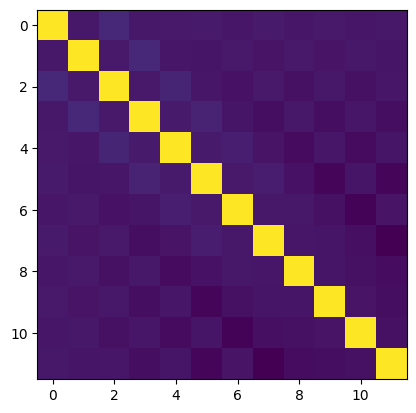

In [61]:
plt.imshow(Base_product.cpu().numpy())

In [62]:
import gc
gc.collect()

647

### Calculating source primary field and prescribed azimuthal flow SH coefficients

In [175]:
# x, y, z = define_3d_grid_for_vector_SH_transform(globals()['sh'])
# S0_r = torch.zeros([globals()['nr_r_samples'],globals()['gamma_max']]).to(device)
# for r_ind in range(globals()['nr_r_samples']):
#     S0_r[r_ind], el, em, l2 = compute_poloidal_source_coefficients(globals()['Br_test'], x, y, z, globals()['sh'], globals()['r_samples'], r_ind, globals()['R_oc']) #torch.tensor(1.0).to(device)

/tmp/ipykernel_146946/929208234.py:33: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  qlm = torch.Tensor(qlm).to(device)


In [63]:
t_10 = compute_toroidal_flow_coefficients_vectorized(globals()['r_samples'], globals()['Omega'], torch.tensor(1.0).to(device)) #globals()['R_oc']
t_10 = torch.tensor(t_10, dtype=torch.complex64).to(device)

/tmp/ipykernel_177512/1565104412.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_10 = torch.tensor(t_10, dtype=torch.complex64).to(device)


# SOLVING THE STURM-LIOUVILLE REPRESENTATION OF THE BG EQUATIONS FOR THE INDUCED POLOIDAL FIELDS

In [64]:
def K_SL(r, eta):
    K_sl = eta*r**2
    return K_sl

def c_SL(r):
    return r

def rho_SL(r):
    return r

def alpha_SL(tau, r, sh_two_index, eta, el, elsasser):
    degree = el[sh_two_index]
    e_gamma = elsasser[sh_two_index, sh_two_index]
    rho_sl = r**2*tau*e_gamma/(4*torch.pi) - eta*degree*(degree+1)

In [65]:
def q_SL(S0_r, psi_r, sh_two_index, c_SL, rho_SL):
    S0_gamma = torch.squeeze(S0_r[:,sh_two_index])
    resolution = S0_r.shape[0]
    
    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)
    
    psi_gamma = torch.squeeze(psi_r[:, :, sh_two_index])

    weight = c_sl*rho_sl

    # Compute all integrals at once
    q_sl_num = torch.einsum('...r,...rj,...r->...j', S0_gamma, psi_gamma, weight) * dr
    q_sl_denom = torch.einsum('rj,rj,...r->...j', psi_gamma, psi_gamma, weight) * dr
    q_sl = q_sl_num/q_sl_denom
    return q_sl

In [66]:
r = torch.linspace(globals()['r0'], globals()['r1'], globals()['nr_r_samples'], device=device)
c_sl = c_SL(r)
rho_sl = rho_SL(r)

In [67]:
k_sl = K_SL(r, globals()['eta']) 

In [68]:
def lambda_SL(sh_two_index, k_sl, c_sl, rho_sl,psi_r, psi_prime_r):

    eval_deriv = -(k_sl[24]-k_sl[0]) * (psi_r[24,:,sh_two_index]-psi_r[0,:,sh_two_index]) * (psi_prime_r[24,:,sh_two_index]-psi_prime_r[0,:,sh_two_index])
      
    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)
    
    psi_gamma = torch.squeeze(psi_r[:, :, sh_two_index])
    psi_prime_gamma = torch.squeeze(psi_prime_r[:, :, sh_two_index])

    weight_k = k_sl
    weight_c_rho = c_sl*rho_sl

    # Compute all integrals at once
    lambda_sl_num = torch.einsum('rj,rj,...r->...j', psi_prime_gamma, psi_prime_gamma, weight_k) * dr
    lambda_sl_denom = torch.einsum('rj,rj,...r->...j', psi_gamma, psi_gamma, weight_c_rho) * dr
    lambda_sl = (eval_deriv + lambda_sl_num)/lambda_sl_denom
    return lambda_sl

In [69]:
lambdas = torch.zeros(globals()['band_nr']-globals()['min_pol_degr'],globals()['gamma_max']).to(device)
qs = torch.zeros(globals()['band_nr']-globals()['min_pol_degr'],globals()['gamma_max']).to(device)
for gamma_two_index in range(1,globals()['gamma_max']):
    qs[:,gamma_two_index] = q_SL(S0_r, globals()['PSI_MATRIX'], gamma_two_index, c_SL, rho_SL)
    lambdas[:,gamma_two_index] = lambda_SL(gamma_two_index, k_sl, c_sl, rho_sl,globals()['PSI_MATRIX'], globals()['PSI_PRIME_MX'])

# Reconstruct the induced mf

In [110]:
time_steps = 20

In [111]:
S_induced = torch.zeros([globals()['nr_r_samples'],globals()['gamma_max'], time_steps]).to(device)

In [112]:
for time_step in range(time_steps):
    print(time_step, flush=True)
    for gamma_two_index in range(1,globals()['gamma_max']):
        r_ind = 0
        for r in r_samples:
            psi_gamma = torch.squeeze(globals()['PSI_MATRIX'][r_ind,:,gamma_two_index])
            q_gamma = torch.squeeze(qs[:,gamma_two_index])
            lambda_gamma = torch.squeeze(lambdas[:,gamma_two_index])
            ksi_gamma_r = psi_gamma * q_gamma
            time_decay = torch.exp(lambda_gamma*time_step)#.expand(1,)
            S_induced[r_ind,gamma_two_index-1,time_step] = torch.matmul(ksi_gamma_r,time_decay.T)
            r_ind += 1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [113]:
S_induced_np = torch.squeeze(S_induced[:,:,19]).cpu().numpy()

## Plot induced poloidal field values

In [114]:
def define_3d_grid_for_vector_SH_transform(sh, theta_mesh, lambda_mesh):
    r = sh.spat_array()  # a spatial array, same as numpy.zeros(sh.spat_shape)
    r[:,:] = 3.48e6
    t = r.copy()
    t[:, :] = theta_mesh
    l = r.copy()
    l[:, :] = lambda_mesh
    return r, t, l

In [115]:
theta_arr = np.linspace(0,pi,90)
lambda_arr = np.linspace(0,2*pi,180)
theta_mesh, lambda_mesh = np.meshgrid(theta_arr, lambda_arr)
Vr, Vt, Vp = define_3d_grid_for_vector_SH_transform(sh, theta_mesh.T, lambda_mesh.T)

In [116]:
Qlm_result = np.zeros(105,).astype(complex)
Tlm_result = np.zeros(105,).astype(complex)

In [117]:
Slm_result = np.squeeze(S_induced_np[99,:]).astype(complex)

In [118]:
# Now (Qlm, Slm, Tlm) represent the vector fields in SHTns
# You can directly synthesize them to a spatial grid:
sh.SHqst_to_spat(Qlm_result, Slm_result, Tlm_result, Vr, Vt, Vp)

## Map of induced magnetic field data at depth ...

#### Induced field at the 4th time step

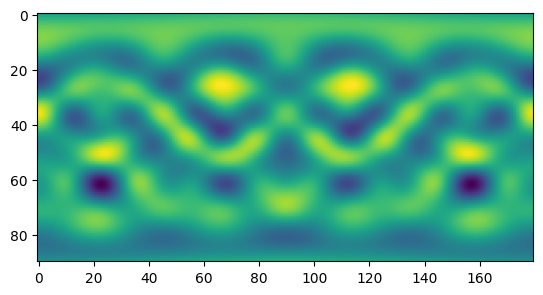

In [106]:
plt.imshow(Vt)

In [109]:
np.max(Vt)

np.float64(5.393237315217631)

#### Induced field at the 20th time step

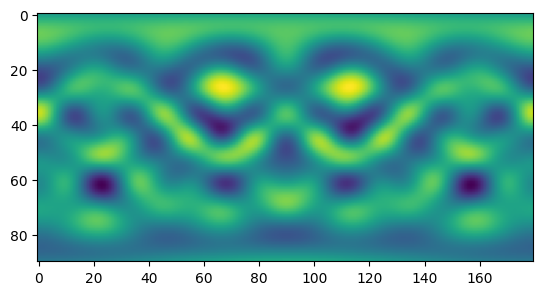

In [119]:
plt.imshow(Vt)

In [206]:
# l2 = el * (el + 1)

In [207]:
# #---------------- RECONSTRUCTING SOLUTION MF AT OBSERVATION RADIUS r FROM SOLUTION COEFFICIENTS Sij(r) ---------------------------
# #l2_np = l2.cpu().numpy()
# r_np = r_samples[99].cpu().numpy()
# qij = S_induced_np[99,:]*(l2+1)/r_np


In [208]:
# #qij = qij.cpu().numpy()
# q_res = sh.spec_array()
# q_res = qij
# q_res = q_res.astype(dtype=complex)

In [209]:
# B_r_reconstr = sh.synth(q_res)

### TODO: SHOULDN'T THIS RETURN THE INITIAL FIELD?

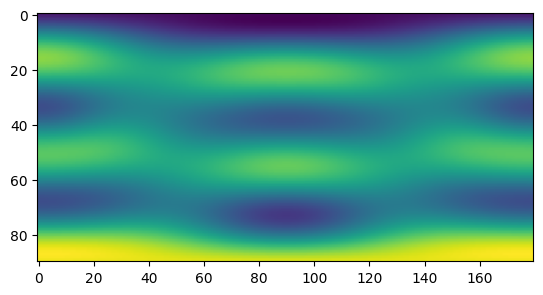

In [210]:
plt.imshow(np.real(B_r_reconstr))

In [211]:
np.max(np.real(B_r_reconstr))

np.float64(172.12719211894978)

#### Induced field at the 5th time step

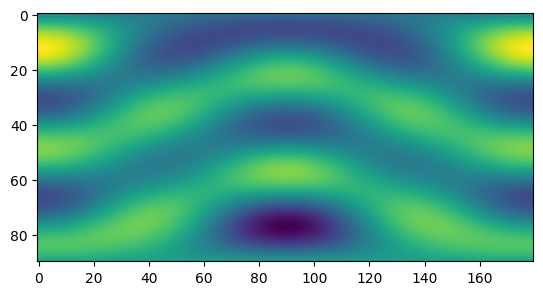

In [196]:
plt.imshow(np.real(B_r_reconstr))

In [197]:
np.max(np.real(B_r_reconstr))

np.float64(5.760745710084234)

#### Induced field at the 9th time step

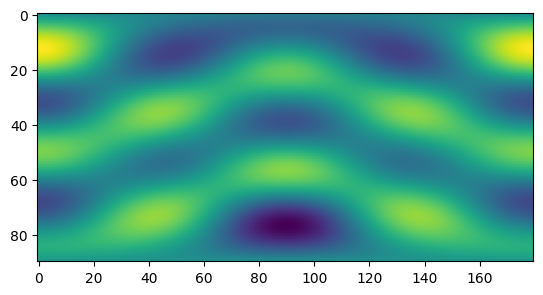

In [203]:
plt.imshow(np.real(B_r_reconstr))

In [204]:
np.max(np.real(B_r_reconstr))

np.float64(5.94189789302237)

## Map of primary magnetic field data of the sourc at depth ...

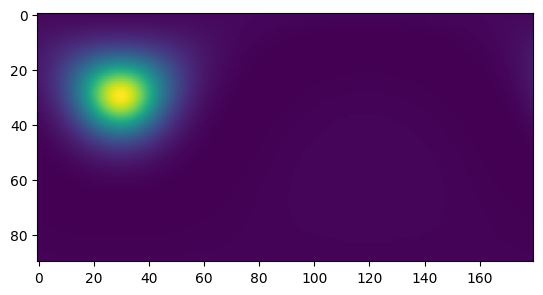

In [336]:
plt.imshow(Br_test[:,:,24].cpu().numpy())

In [260]:
np.max(globals()['Br_test'][:,:,23].cpu().numpy())

np.float32(6.31631e-06)